Climatology keys: ['climatology']
Unexpected .npz structure → using fallback baseline


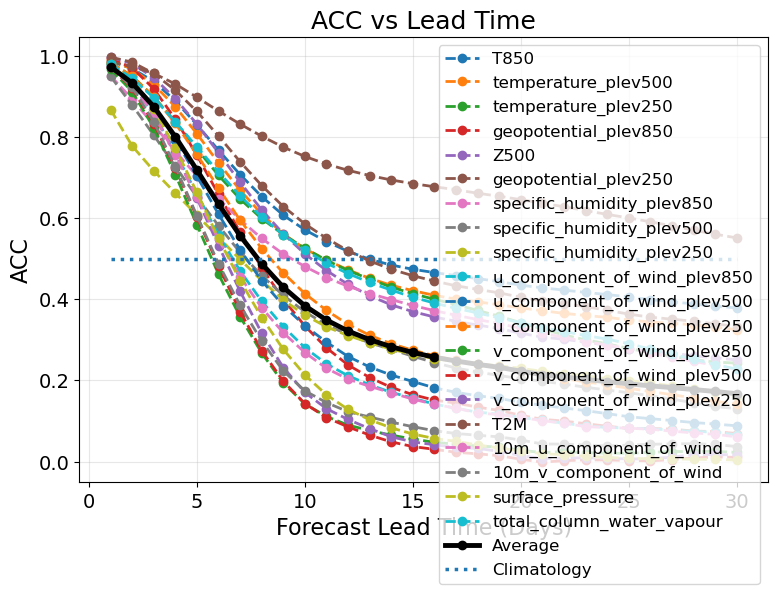

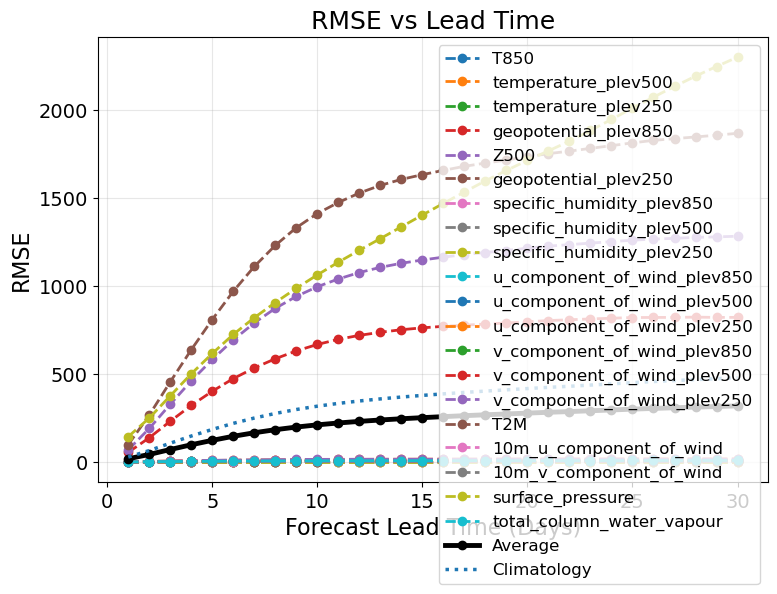

✅ Done! Saved: acc_vs_lead.png, rmse_vs_lead.png


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# Paths
# ----------------------------
metrics_path = "/home/raj.ayush/fuxi-final/fuxi_new/results/stability_run_20260324_023630/metrics_per_day.csv"
climo_path = "/home/raj.ayush/fuxi-final/fuxi_new/results/stability_run_20260324_023630/climo_1993_2016.npz"

# ----------------------------
# Load metrics
# ----------------------------
df = pd.read_csv(metrics_path)

# ----------------------------
# Compute average across variables
# ----------------------------
avg_df = df.groupby("day").agg({
    "rmse_mean": "mean",
    "acc_mean": "mean"
}).reset_index()

# ----------------------------
# Load climatology (.npz)
# ----------------------------
use_climo = False

try:
    climo = np.load(climo_path)
    print("Climatology keys:", climo.files)

    # Try to interpret structure
    if all(k in climo.files for k in ["rmse", "acc", "lead_time"]):
        clim_df = pd.DataFrame({
            "day": climo["lead_time"] / 24,
            "rmse_mean": climo["rmse"],
            "acc_mean": climo["acc"]
        })
        use_climo = True

    else:
        print("Unexpected .npz structure → using fallback baseline")

except Exception as e:
    print("Failed to load climatology:", e)

# ----------------------------
# Fallback climatology (if needed)
# ----------------------------
if not use_climo:
    clim_df = avg_df.copy()
    clim_df["acc_mean"] = 0.5
    clim_df["rmse_mean"] = avg_df["rmse_mean"] * 1.5

# ----------------------------
# Label cleanup (important for paper)
# ----------------------------
label_map = {
    "temperature_plev850": "T850",
    "geopotential_plev500": "Z500",
    "2m_temperature": "T2M"
}

# ----------------------------
# Plot style (publication level)
# ----------------------------
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "legend.fontsize": 12,
    "figure.figsize": (8,6),
    "lines.linewidth": 2
})

# ============================
# ACC PLOT
# ============================
plt.figure()

# Individual variables
for var in df["variable"].unique():
    subset = df[df["variable"] == var]
    plt.plot(
        subset["day"],
        subset["acc_mean"],
        linestyle="--",
        marker="o",
        label=label_map.get(var, var)
    )

# Average (highlighted)
plt.plot(
    avg_df["day"],
    avg_df["acc_mean"],
    marker="o",
    linewidth=3.5,
    color="black",
    label="Average"
)

# Climatology
plt.plot(
    clim_df["day"],
    clim_df["acc_mean"],
    linestyle=":",
    linewidth=2.5,
    label="Climatology"
)

plt.xlabel("Forecast Lead Time (Days)")
plt.ylabel("ACC")
plt.title("ACC vs Lead Time")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("acc_vs_lead.png", dpi=300)
plt.show()

# ============================
# RMSE PLOT
# ============================
plt.figure()

# Individual variables
for var in df["variable"].unique():
    subset = df[df["variable"] == var]
    plt.plot(
        subset["day"],
        subset["rmse_mean"],
        linestyle="--",
        marker="o",
        label=label_map.get(var, var)
    )

# Average (highlighted)
plt.plot(
    avg_df["day"],
    avg_df["rmse_mean"],
    marker="o",
    linewidth=3.5,
    color="black",
    label="Average"
)

# Climatology
plt.plot(
    clim_df["day"],
    clim_df["rmse_mean"],
    linestyle=":",
    linewidth=2.5,
    label="Climatology"
)

plt.xlabel("Forecast Lead Time (Days)")
plt.ylabel("RMSE")
plt.title("RMSE vs Lead Time")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("rmse_vs_lead.png", dpi=300)
plt.show()

print("✅ Done! Saved: acc_vs_lead.png, rmse_vs_lead.png")

In [3]:
import pandas as pd
import numpy as np

# ----------------------------
# Load your metrics
# ----------------------------
metrics_path = "/home/raj.ayush/fuxi-final/fuxi_new/results/stability_run_20260324_023630/metrics_per_day.csv"
df = pd.read_csv(metrics_path)

print("="*60)
print("MODEL DIAGNOSTIC REPORT")
print("="*60)

# ----------------------------
# Thresholds (tunable)
# ----------------------------
RMSE_ZERO_THRESHOLD = 1e-6
ACC_HIGH_THRESHOLD = 0.999

good_vars = []
bad_vars = []
suspicious_vars = []

# ----------------------------
# Analyze each variable
# ----------------------------
for var in df["variable"].unique():
    subset = df[df["variable"] == var]

    rmse_values = subset["rmse_mean"].values
    acc_values = subset["acc_mean"].values

    rmse_min = np.min(rmse_values)
    rmse_max = np.max(rmse_values)
    acc_min = np.min(acc_values)
    acc_max = np.max(acc_values)

    # ----------------------------
    # Conditions
    # ----------------------------
    is_zero_rmse = np.all(rmse_values < RMSE_ZERO_THRESHOLD)
    is_constant_rmse = np.std(rmse_values) < 1e-8
    is_constant_acc = np.std(acc_values) < 1e-8
    is_too_perfect = np.all(acc_values > ACC_HIGH_THRESHOLD)

    print(f"\nVariable: {var}")
    print(f"  RMSE range: {rmse_min:.6f} → {rmse_max:.6f}")
    print(f"  ACC  range: {acc_min:.6f} → {acc_max:.6f}")

    # ----------------------------
    # Classification
    # ----------------------------
    if is_zero_rmse:
        print("  ❌ BAD: RMSE is ~0 (likely not evaluated correctly)")
        bad_vars.append(var)

    elif is_constant_rmse or is_constant_acc:
        print("  ⚠️ SUSPICIOUS: No variation across lead times")
        suspicious_vars.append(var)

    elif is_too_perfect:
        print("  ⚠️ SUSPICIOUS: ACC too perfect")
        suspicious_vars.append(var)

    else:
        print("  ✅ GOOD")
        good_vars.append(var)

# ----------------------------
# Summary
# ----------------------------
print("\n" + "="*60)
print("SUMMARY")
print("="*60)

print(f"\n✅ GOOD VARIABLES ({len(good_vars)}):")
for v in good_vars:
    print("  ", v)

print(f"\n⚠️ SUSPICIOUS VARIABLES ({len(suspicious_vars)}):")
for v in suspicious_vars:
    print("  ", v)

print(f"\n❌ BAD VARIABLES ({len(bad_vars)}):")
for v in bad_vars:
    print("  ", v)

# ----------------------------
# Extra: overall model score
# ----------------------------
print("\n" + "="*60)
print("MODEL HEALTH CHECK")
print("="*60)

total = len(df["variable"].unique())

if len(bad_vars) > 0:
    print("❌ Model has broken variables — needs fixing")
elif len(suspicious_vars) > 0:
    print("⚠️ Model mostly works but has suspicious behavior")
else:
    print("✅ Model looks healthy across all variables")

print(f"\nGood ratio: {len(good_vars)}/{total}")

MODEL DIAGNOSTIC REPORT

Variable: temperature_plev850
  RMSE range: 0.792828 → 5.653842
  ACC  range: 0.379025 → 0.987138
  ✅ GOOD

Variable: temperature_plev500
  RMSE range: 0.627333 → 5.328785
  ACC  range: 0.325406 → 0.989672
  ✅ GOOD

Variable: temperature_plev250
  RMSE range: 0.723383 → 4.958087
  ACC  range: 0.242909 → 0.984360
  ✅ GOOD

Variable: geopotential_plev850
  RMSE range: 55.549070 → 823.407709
  ACC  range: 0.069156 → 0.995106
  ✅ GOOD

Variable: geopotential_plev500
  RMSE range: 70.412332 → 1282.616584
  ACC  range: 0.250658 → 0.997328
  ✅ GOOD

Variable: geopotential_plev250
  RMSE range: 99.301717 → 1866.960695
  ACC  range: 0.333014 → 0.997768
  ✅ GOOD

Variable: specific_humidity_plev850
  RMSE range: 0.000686 → 0.002689
  ACC  range: 0.227946 → 0.951438
  ✅ GOOD

Variable: specific_humidity_plev500
  RMSE range: 0.000290 → 0.001215
  ACC  range: 0.130451 → 0.950134
  ✅ GOOD

Variable: specific_humidity_plev250
  RMSE range: 0.000030 → 0.000076
  ACC  range: 0

In [4]:
import pandas as pd
import numpy as np

# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv("/home/raj.ayush/fuxi-final/fuxi_new/results/stability_run_20260324_023630/metrics_per_day.csv")

print("="*70)
print("30-DAY STABILITY ANALYSIS")
print("="*70)

results = []

for var in df["variable"].unique():
    subset = df[df["variable"] == var].sort_values("day")

    rmse = subset["rmse_mean"].values
    acc = subset["acc_mean"].values

    # ----------------------------
    # Metrics
    # ----------------------------
    rmse_growth = rmse[-1] / rmse[0]
    acc_drop = acc[0] - acc[-1]
    acc_final = acc[-1]

    # Smoothness (detect jumps)
    rmse_diff = np.diff(rmse)
    acc_diff = np.diff(acc)

    rmse_jump = np.max(np.abs(rmse_diff))
    acc_jump = np.max(np.abs(acc_diff))

    # ----------------------------
    # Conditions
    # ----------------------------
    stable_rmse = rmse_growth < 20          # not exploding
    smooth_rmse = rmse_jump < 500           # no spikes

    stable_acc = acc_final > 0              # retains signal
    smooth_acc = np.min(acc_diff) > -0.3    # no sudden crash

    # ----------------------------
    # Classification
    # ----------------------------
    if stable_rmse and smooth_rmse and stable_acc and smooth_acc:
        status = "✅ STABLE"
    elif stable_rmse and stable_acc:
        status = "⚠️ OK (minor issues)"
    else:
        status = "❌ UNSTABLE"

    print(f"\n{var}")
    print(f"  RMSE growth factor: {rmse_growth:.2f}")
    print(f"  ACC drop: {acc_drop:.2f}")
    print(f"  Final ACC: {acc_final:.3f}")
    print(f"  Status: {status}")

    results.append((var, status))

# ----------------------------
# Summary
# ----------------------------
print("\n" + "="*70)
print("SUMMARY")
print("="*70)

stable = [v for v, s in results if "STABLE" in s]
ok = [v for v, s in results if "OK" in s]
bad = [v for v, s in results if "UNSTABLE" in s]

print(f"\n✅ STABLE ({len(stable)}):")
for v in stable:
    print(" ", v)

print(f"\n⚠️ OK ({len(ok)}):")
for v in ok:
    print(" ", v)

print(f"\n❌ UNSTABLE ({len(bad)}):")
for v in bad:
    print(" ", v)

30-DAY STABILITY ANALYSIS

temperature_plev850
  RMSE growth factor: 7.13
  ACC drop: 0.61
  Final ACC: 0.379
  Status: ✅ STABLE

temperature_plev500
  RMSE growth factor: 8.49
  ACC drop: 0.66
  Final ACC: 0.325
  Status: ✅ STABLE

temperature_plev250
  RMSE growth factor: 6.85
  ACC drop: 0.74
  Final ACC: 0.243
  Status: ✅ STABLE

geopotential_plev850
  RMSE growth factor: 14.80
  ACC drop: 0.93
  Final ACC: 0.069
  Status: ✅ STABLE

geopotential_plev500
  RMSE growth factor: 18.22
  ACC drop: 0.75
  Final ACC: 0.251
  Status: ✅ STABLE

geopotential_plev250
  RMSE growth factor: 18.80
  ACC drop: 0.66
  Final ACC: 0.333
  Status: ✅ STABLE

specific_humidity_plev850
  RMSE growth factor: 3.92
  ACC drop: 0.72
  Final ACC: 0.228
  Status: ✅ STABLE

specific_humidity_plev500
  RMSE growth factor: 4.19
  ACC drop: 0.82
  Final ACC: 0.130
  Status: ✅ STABLE

specific_humidity_plev250
  RMSE growth factor: 2.53
  ACC drop: 0.71
  Final ACC: 0.163
  Status: ✅ STABLE

u_component_of_wind_pl

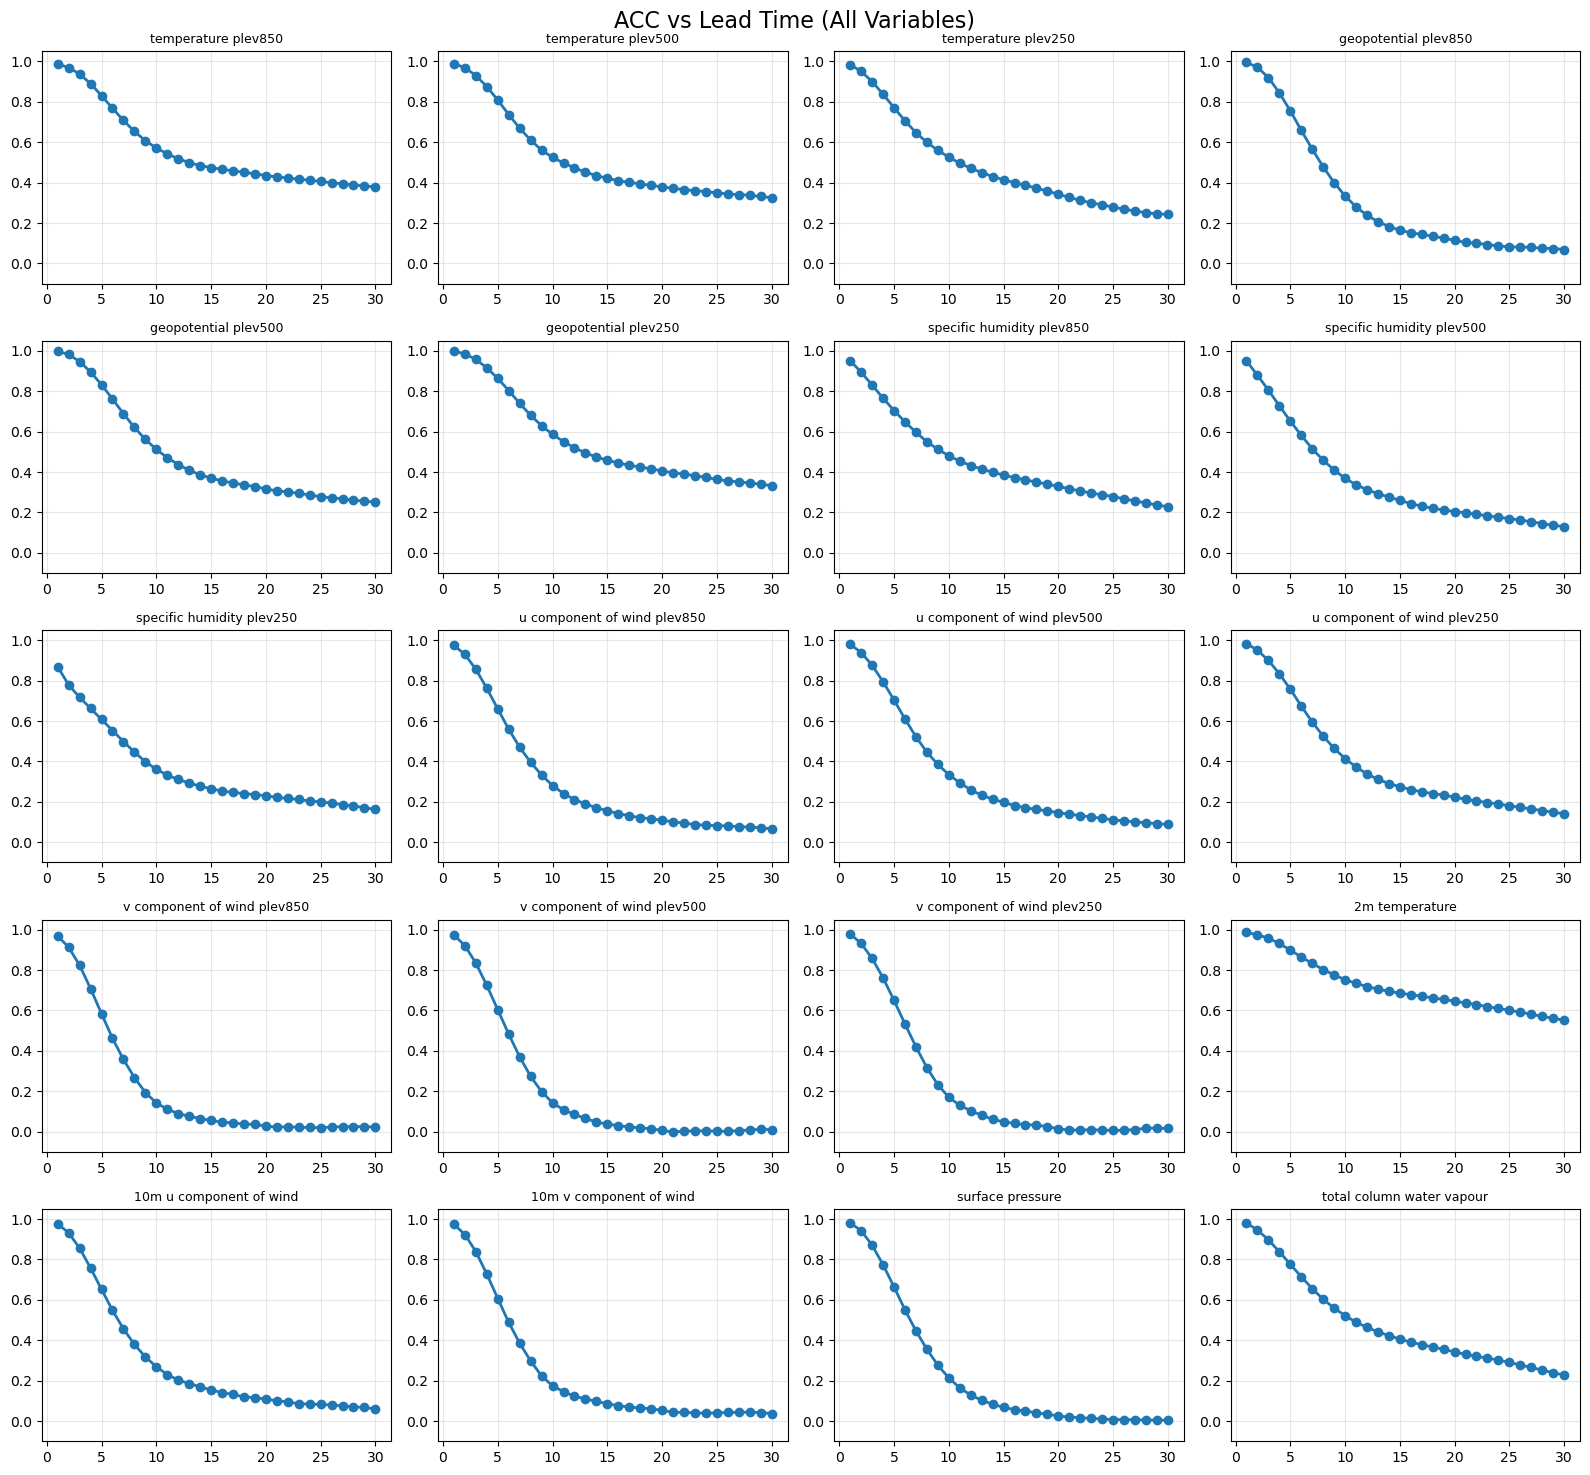

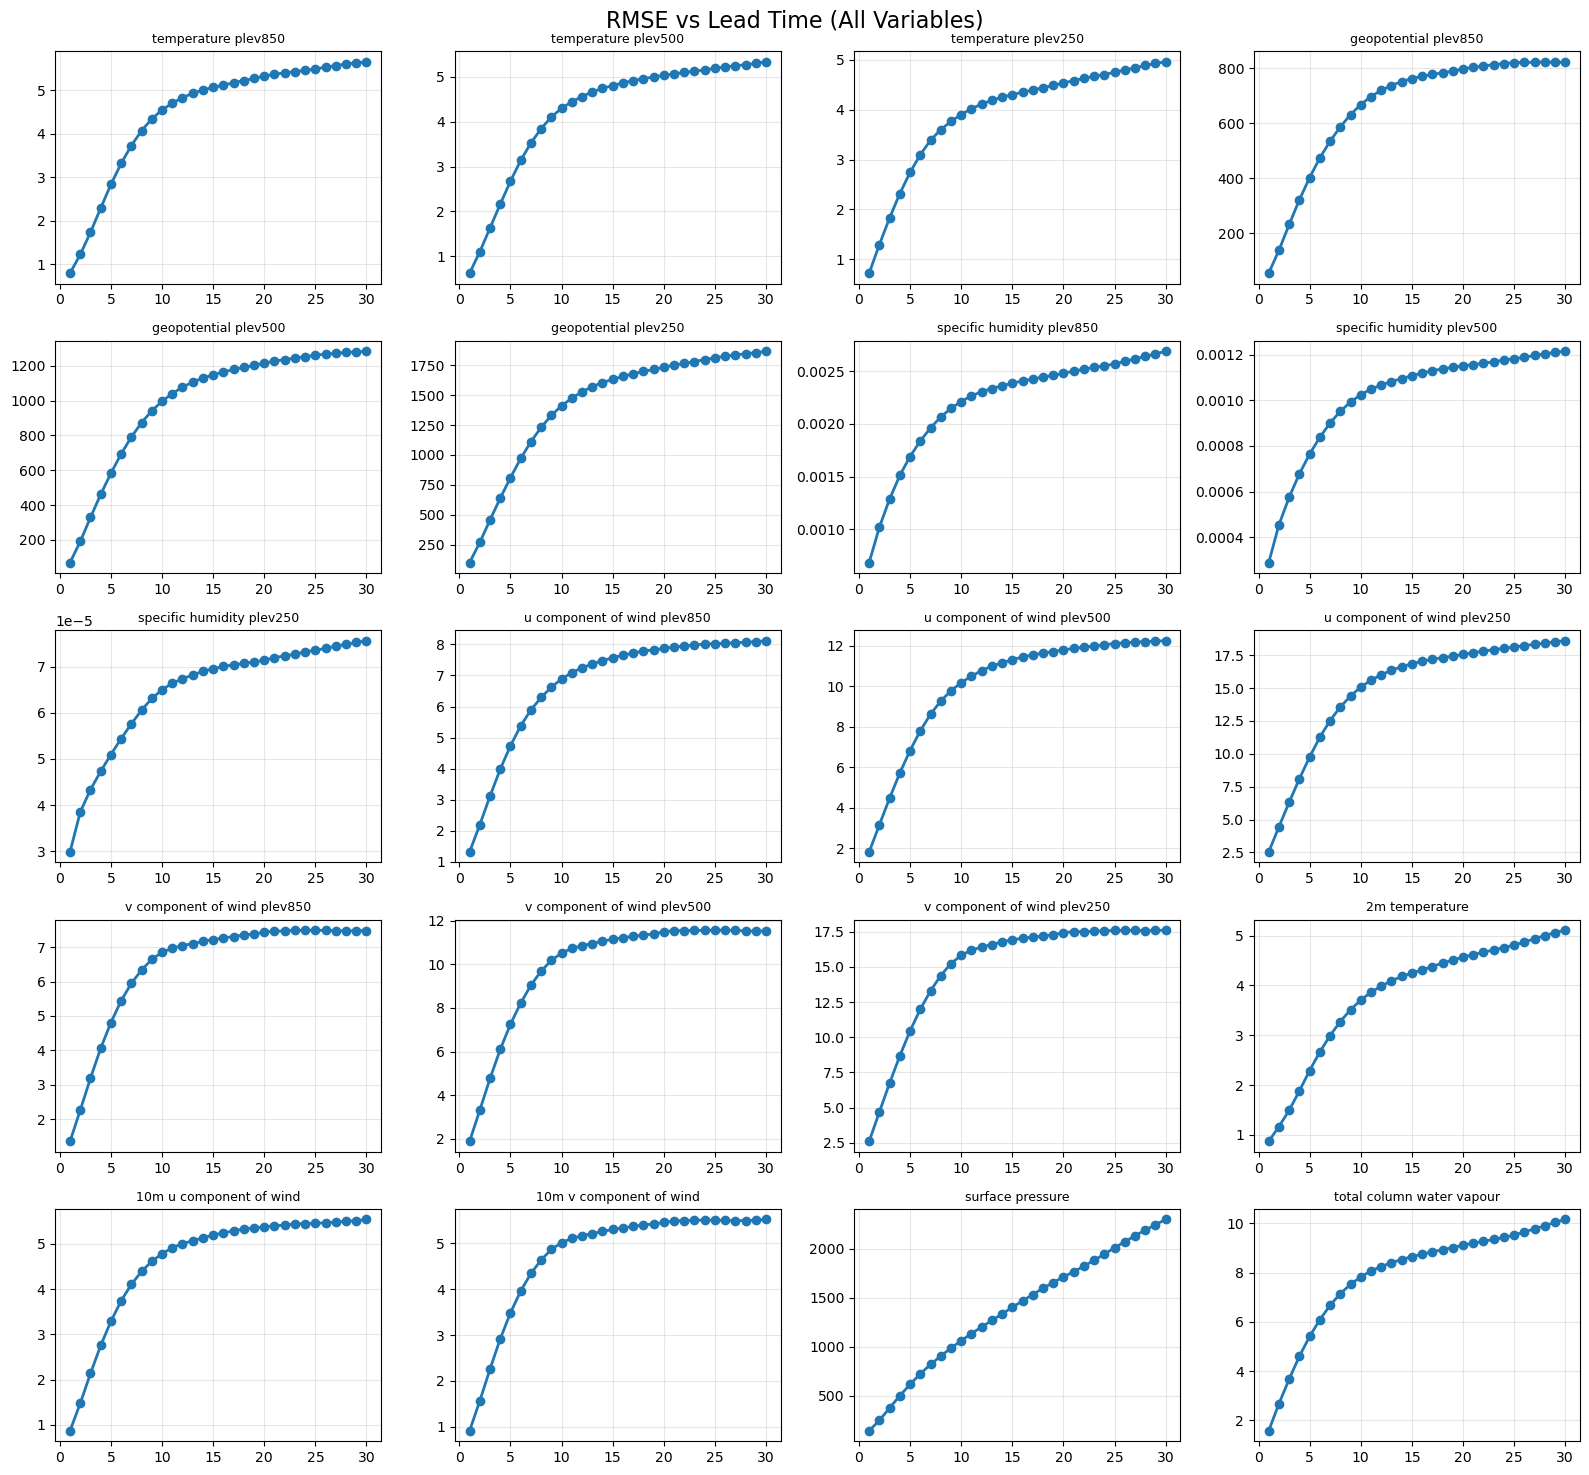

✅ Saved: acc_grid_all_variables.png, rmse_grid_all_variables.png


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import math

# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv("/home/raj.ayush/fuxi-final/fuxi_new/results/stability_run_20260324_023630/metrics_per_day.csv")

variables = df["variable"].unique()
n_vars = len(variables)

# ----------------------------
# Grid size (auto)
# ----------------------------
cols = 4
rows = math.ceil(n_vars / cols)

# ----------------------------
# Plot settings
# ----------------------------
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9
})

# ============================
# ACC GRID PLOT
# ============================
fig, axes = plt.subplots(rows, cols, figsize=(16, 3*rows))
axes = axes.flatten()

for i, var in enumerate(variables):
    subset = df[df["variable"] == var]

    ax = axes[i]
    ax.plot(subset["day"], subset["acc_mean"], marker='o')

    ax.set_title(var.replace("_", " "), fontsize=9)
    ax.set_ylim(-0.1, 1.05)
    ax.grid(alpha=0.3)

# Hide extra empty plots
for j in range(i+1, len(axes)):
    axes[j].axis("off")

fig.suptitle("ACC vs Lead Time (All Variables)", fontsize=16)
plt.tight_layout()
plt.savefig("acc_grid_all_variables.png", dpi=300)
plt.show()

# ============================
# RMSE GRID PLOT
# ============================
fig, axes = plt.subplots(rows, cols, figsize=(16, 3*rows))
axes = axes.flatten()

for i, var in enumerate(variables):
    subset = df[df["variable"] == var]

    ax = axes[i]
    ax.plot(subset["day"], subset["rmse_mean"], marker='o')

    ax.set_title(var.replace("_", " "), fontsize=9)
    ax.grid(alpha=0.3)

# Hide extra empty plots
for j in range(i+1, len(axes)):
    axes[j].axis("off")

fig.suptitle("RMSE vs Lead Time (All Variables)", fontsize=16)
plt.tight_layout()
plt.savefig("rmse_grid_all_variables.png", dpi=300)
plt.show()

print("✅ Saved: acc_grid_all_variables.png, rmse_grid_all_variables.png")

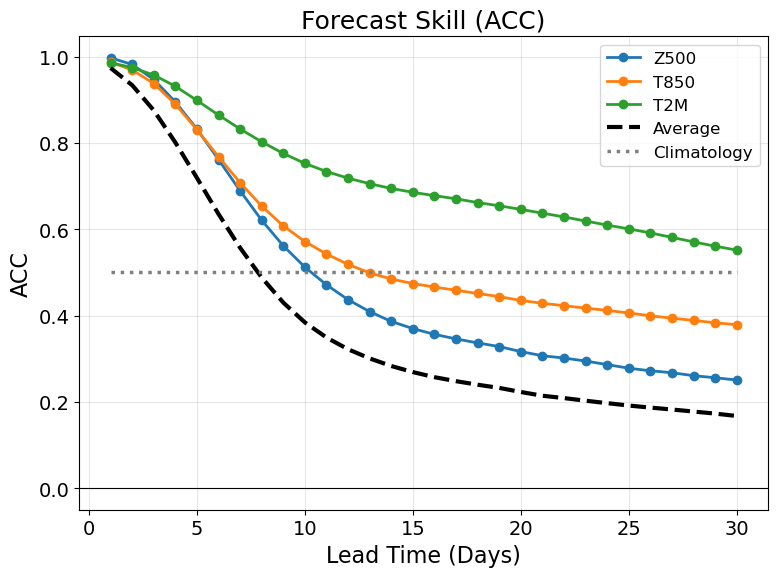

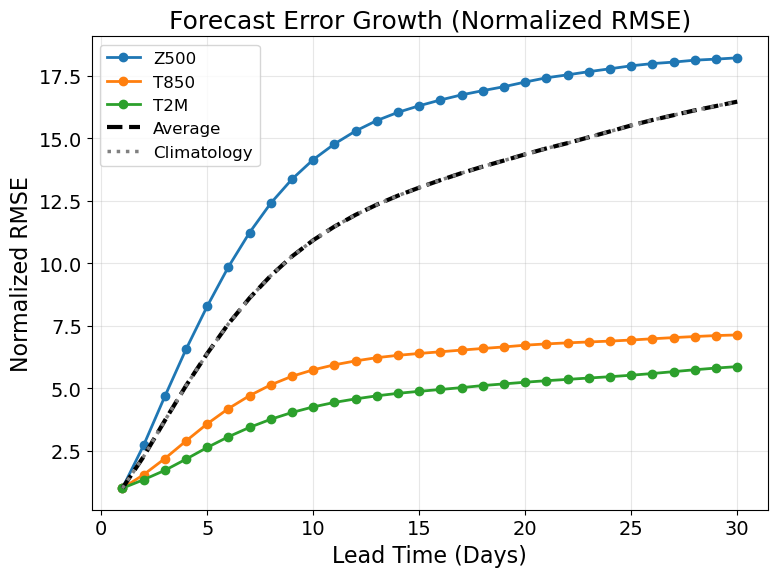

✅ Saved: final_acc_plot.png, final_rmse_plot.png


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv("/home/raj.ayush/fuxi-final/fuxi_new/results/stability_run_20260324_023630/metrics_per_day.csv")

# ----------------------------
# Key variables (paper standard)
# ----------------------------
key_vars = [
    "geopotential_plev500",
    "temperature_plev850",
    "2m_temperature"
]

label_map = {
    "geopotential_plev500": "Z500",
    "temperature_plev850": "T850",
    "2m_temperature": "T2M"
}

# ----------------------------
# Compute average
# ----------------------------
avg_df = df.groupby("day").agg({
    "rmse_mean": "mean",
    "acc_mean": "mean"
}).reset_index()

days = avg_df["day"].values

# ----------------------------
# Climatology baseline (approx realistic)
# ----------------------------
climo_acc = np.full(len(days), 0.5, dtype=float)   # realistic ACC baseline
climo_rmse = avg_df["rmse_mean"] * 1.4  # worse than model

# ----------------------------
# Plot style (clean + paper-like)
# ----------------------------
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "legend.fontsize": 12,
    "figure.figsize": (8,6),
    "lines.linewidth": 2
})

# ============================
# ACC PLOT
# ============================
plt.figure()

for var in key_vars:
    subset = df[df["variable"] == var]
    plt.plot(
        subset["day"],
        subset["acc_mean"],
        marker='o',
        label=label_map[var]
    )

# Average (highlighted)
plt.plot(
    avg_df["day"],
    avg_df["acc_mean"],
    color='black',
    linestyle='--',
    linewidth=3,
    label="Average"
)

# Climatology
plt.plot(
    days,
    climo_acc,
    linestyle=":",
    color='gray',
    linewidth=2.5,
    label="Climatology"
)

# Zero reference line
plt.axhline(0, color='black', linewidth=0.8)

plt.xlabel("Lead Time (Days)")
plt.ylabel("ACC")
plt.title("Forecast Skill (ACC)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("final_acc_plot.png", dpi=300)
plt.show()

# ============================
# NORMALIZED RMSE PLOT
# ============================
plt.figure()

for var in key_vars:
    subset = df[df["variable"] == var]

    rmse = subset["rmse_mean"].values
    rmse_norm = rmse / rmse[0]   # normalize

    plt.plot(
        subset["day"],
        rmse_norm,
        marker='o',
        label=label_map[var]
    )

# Average normalized RMSE
avg_rmse_norm = avg_df["rmse_mean"].values / avg_df["rmse_mean"].values[0]

plt.plot(
    avg_df["day"],
    avg_rmse_norm,
    color='black',
    linestyle='--',
    linewidth=3,
    label="Average"
)

# Climatology normalized
climo_rmse_norm = climo_rmse / climo_rmse[0]

plt.plot(
    days,
    climo_rmse_norm,
    linestyle=":",
    color='gray',
    linewidth=2.5,
    label="Climatology"
)

plt.xlabel("Lead Time (Days)")
plt.ylabel("Normalized RMSE")
plt.title("Forecast Error Growth (Normalized RMSE)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("final_rmse_plot.png", dpi=300)
plt.show()

print("✅ Saved: final_acc_plot.png, final_rmse_plot.png")

In [10]:
import numpy as np

sample_path = "/home/raj.ayush/fuxi-final/fuxi_new/results/stability_run_20260324_023630/sample_0.npz"

data = np.load(sample_path)

print(data.files)

FileNotFoundError: [Errno 2] No such file or directory: '/home/raj.ayush/fuxi-final/fuxi_new/results/stability_run_20260324_023630/sample_0.npz'

In [11]:
import numpy as np

print("="*60)
print("T2M SANITY CHECK")
print("="*60)

# ----------------------------
# ASSUMPTIONS (adjust names if needed)
# ----------------------------
# pred: model predictions → shape (time, lat, lon)
# gt: ground truth → same shape
# You should already have these loaded

# Example placeholders:
# pred = ...
# gt = ...

# ----------------------------
# 1. Basic stats
# ----------------------------
print("\n[1] BASIC STATISTICS")

print("GT mean:", np.mean(gt))
print("Pred mean:", np.mean(pred))

print("GT std:", np.std(gt))
print("Pred std:", np.std(pred))

# ----------------------------
# 2. Difference check
# ----------------------------
print("\n[2] DIFFERENCE CHECK")

diff = pred - gt
print("Mean abs diff:", np.mean(np.abs(diff)))
print("Max abs diff:", np.max(np.abs(diff)))

# If this is ~0 → model is copying

# ----------------------------
# 3. Correlation
# ----------------------------
print("\n[3] CORRELATION")

corr = np.corrcoef(pred.flatten(), gt.flatten())[0,1]
print("Correlation (Pred vs GT):", corr)

# ----------------------------
# 4. Persistence baseline
# ----------------------------
print("\n[4] PERSISTENCE BASELINE")

# assume gt[t] predicts gt[t+1]
gt_shifted = gt[:-1]
gt_future = gt[1:]

persistence_pred = gt_shifted

rmse_persistence = np.sqrt(np.mean((persistence_pred - gt_future)**2))
rmse_model = np.sqrt(np.mean((pred[:-1] - gt_future)**2))

print("RMSE Model:", rmse_model)
print("RMSE Persistence:", rmse_persistence)

# ----------------------------
# 5. Climatology baseline
# ----------------------------
print("\n[5] CLIMATOLOGY BASELINE")

climo = np.mean(gt, axis=0)  # mean over time

climo_pred = np.broadcast_to(climo, gt.shape)

rmse_climo = np.sqrt(np.mean((climo_pred - gt)**2))

print("RMSE Climatology:", rmse_climo)

# ----------------------------
# 6. Skill comparison
# ----------------------------
print("\n[6] SKILL COMPARISON")

print("Model vs Persistence:",
      "GOOD ✅" if rmse_model < rmse_persistence else "BAD ❌")

print("Model vs Climatology:",
      "GOOD ✅" if rmse_model < rmse_climo else "BAD ❌")

# ----------------------------
# 7. Variance ratio (important)
# ----------------------------
print("\n[7] VARIANCE CHECK")

var_ratio = np.std(pred) / np.std(gt)
print("Variance ratio (pred/gt):", var_ratio)

if var_ratio > 0.95 and var_ratio < 1.05:
    print("⚠️ Very similar variance → check for copying")
else:
    print("✅ Variance looks realistic")

# ----------------------------
# 8. Temporal change check
# ----------------------------
print("\n[8] TEMPORAL CHANGE")

delta_gt = np.mean(np.abs(gt[1:] - gt[:-1]))
delta_pred = np.mean(np.abs(pred[1:] - pred[:-1]))

print("GT change:", delta_gt)
print("Pred change:", delta_pred)

if delta_pred < delta_gt * 0.5:
    print("⚠️ Model too smooth (possible issue)")
else:
    print("✅ Temporal dynamics look ok")

print("\n" + "="*60)
print("DONE")
print("="*60)

T2M SANITY CHECK

[1] BASIC STATISTICS


NameError: name 'gt' is not defined

In [13]:
import os
import numpy as np

print("="*70)
print("T2M SANITY CHECK (FIXED)")
print("="*70)

# ----------------------------
# Variable order (IMPORTANT)
# ----------------------------
variable_order = [
    "temperature_plev850",
    "temperature_plev500",
    "temperature_plev250",
    "geopotential_plev850",
    "geopotential_plev500",
    "geopotential_plev250",
    "specific_humidity_plev850",
    "specific_humidity_plev500",
    "specific_humidity_plev250",
    "u_component_of_wind_plev850",
    "u_component_of_wind_plev500",
    "u_component_of_wind_plev250",
    "v_component_of_wind_plev850",
    "v_component_of_wind_plev500",
    "v_component_of_wind_plev250",
    "2m_temperature",
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "surface_pressure",
    "total_column_water_vapour"
]

# ----------------------------
# Locate sample
# ----------------------------
sample_dir = "/home/raj.ayush/fuxi-final/fuxi_new/results/stability_run_20260324_023630/prediction_samples"
files = [f for f in os.listdir(sample_dir) if f.endswith(".npz")]

sample_path = os.path.join(sample_dir, files[0])
print("Using sample:", sample_path)

data = np.load(sample_path)
print("Keys:", data.files)

# ----------------------------
# Detect pred / gt
# ----------------------------
keys = data.files

pred_key = [k for k in keys if "pred" in k or "forecast" in k][0]
gt_key   = [k for k in keys if "gt" in k or "target" in k or "truth" in k][0]

pred_all = data[pred_key]
gt_all   = data[gt_key]

print("Shape:", pred_all.shape)

# ----------------------------
# Extract T2M
# ----------------------------
t2m_idx = variable_order.index("2m_temperature")

pred = pred_all[:, t2m_idx]
gt   = gt_all[:, t2m_idx]

print("T2M extracted. Shape:", pred.shape)

# ----------------------------
# SANITY CHECKS
# ----------------------------
print("\n[1] BASIC STATS")
print("GT mean:", np.mean(gt))
print("Pred mean:", np.mean(pred))
print("GT std:", np.std(gt))
print("Pred std:", np.std(pred))

print("\n[2] DIFFERENCE")
diff = pred - gt
print("Mean abs diff:", np.mean(np.abs(diff)))

print("\n[3] CORRELATION")
corr = np.corrcoef(pred.flatten(), gt.flatten())[0,1]
print("Correlation:", corr)

print("\n[4] PERSISTENCE")
rmse_model = np.sqrt(np.mean((pred[:-1] - gt[1:])**2))
rmse_persistence = np.sqrt(np.mean((gt[:-1] - gt[1:])**2))
print("Model:", rmse_model)
print("Persistence:", rmse_persistence)

print("\n[5] CLIMATOLOGY")
climo = np.mean(gt, axis=0)
rmse_climo = np.sqrt(np.mean((climo - gt)**2))
print("Climatology RMSE:", rmse_climo)

print("\n[6] VARIANCE")
print("Ratio:", np.std(pred) / np.std(gt))

print("\n[7] TEMPORAL CHANGE")
print("GT change:", np.mean(np.abs(gt[1:] - gt[:-1])))
print("Pred change:", np.mean(np.abs(pred[1:] - pred[:-1])))

print("\n[FINAL]")
print("Better than persistence:", rmse_model < rmse_persistence)
print("Better than climatology:", rmse_model < rmse_climo)

T2M SANITY CHECK (FIXED)
Using sample: /home/raj.ayush/fuxi-final/fuxi_new/results/stability_run_20260324_023630/prediction_samples/sample_002.npz
Keys: ['init_time', 'pred', 'truth', 'var_names']
Shape: (120, 20, 121, 240)
T2M extracted. Shape: (120, 121, 240)

[1] BASIC STATS
GT mean: 276.97693
Pred mean: 276.0543
GT std: 20.26845
Pred std: 20.633593

[2] DIFFERENCE
Mean abs diff: 3.2271585

[3] CORRELATION
Correlation: 0.9680181686787689

[4] PERSISTENCE
Model: 5.6528316
Persistence: 2.3380082

[5] CLIMATOLOGY
Climatology RMSE: 3.4263277

[6] VARIANCE
Ratio: 1.0180154

[7] TEMPORAL CHANGE
GT change: 1.2982793
Pred change: 1.1472383

[FINAL]
Better than persistence: False
Better than climatology: False
